# International Football Data Analysis

This project analyzes historical international football matches using:

- Results Dataset
- Goalscorers Dataset
- Shootouts Dataset
- Former Country Names Dataset

Goal:
- Discover trends
- Analyze team performance
- Study goalscoring patterns
- Explore penalty shootouts

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
results = pd.read_csv("data/results.csv")
goals = pd.read_csv("data/goalscorers.csv")
shootouts = pd.read_csv("data/shootouts.csv")
former = pd.read_csv("data/former_names.csv")

print("✓ Data loaded successfully")
print(f"\nResults: {results.shape}")
print(f"Goalscorers: {goals.shape}")
print(f"Shootouts: {shootouts.shape}")
print(f"Former Names: {former.shape}")

✓ Data loaded successfully

Results: (49437, 9)
Goalscorers: (47601, 8)
Shootouts: (678, 5)
Former Names: (36, 4)


In [4]:
print("\n" + "="*50)
print("RESULTS DATASET")
print("="*50)
print(results.head())
print("\n")
results.info()
print("\n")
print(results.describe())

print("\n" + "="*50)
print("GOALSCORERS DATASET")
print("="*50)
print(goals.head())
print("\n")
goals.info()
print("\n")
print(goals.describe())

print("\n" + "="*50)
print("SHOOTOUTS DATASET")
print("="*50)
print(shootouts.head())
print("\n")
shootouts.info()
print("\n")
print(shootouts.describe())

print("\n" + "="*50)
print("FORMER NAMES DATASET")
print("="*50)
print(former.head())
print("\n")
former.info()
print("\n")
print(former.describe())


RESULTS DATASET
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49437 entries, 0 to 49436
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49437 non-null  object 
 1   home_team   49437 non-null  object 
 2   away_team   49437 non-null  object 
 3   home_score  49365 non-null  float64
 4

In [5]:
print("\n" + "="*50)
print("DATA QUALITY CHECK")
print("="*50)

print("\nResults - Nulls and Duplicates:")
print(f"Null values: {results.isnull().sum().sum()}")
print(f"Duplicate rows: {results.duplicated().sum()}")

print("\nGoalscorers - Nulls and Duplicates:")
print(f"Null values: {goals.isnull().sum().sum()}")
print(f"Duplicate rows: {goals.duplicated().sum()}")

print("\nShootouts - Nulls and Duplicates:")
print(f"Null values: {shootouts.isnull().sum().sum()}")
print(f"Duplicate rows: {shootouts.duplicated().sum()}")

print("\nFormer Names - Nulls and Duplicates:")
print(f"Null values: {former.isnull().sum().sum()}")
print(f"Duplicate rows: {former.duplicated().sum()}")


DATA QUALITY CHECK

Results - Nulls and Duplicates:
Null values: 144
Duplicate rows: 0

Goalscorers - Nulls and Duplicates:
Null values: 304
Duplicate rows: 82

Shootouts - Nulls and Duplicates:
Null values: 430
Duplicate rows: 0

Former Names - Nulls and Duplicates:
Null values: 0
Duplicate rows: 0


In [6]:
results['date'] = pd.to_datetime(results['date'])
goals['date'] = pd.to_datetime(goals['date'])
shootouts['date'] = pd.to_datetime(shootouts['date'])
former['start_date'] = pd.to_datetime(former['start_date'])
former['end_date'] = pd.to_datetime(former['end_date'])

results['year'] = results['date'].dt.year
goals['year'] = goals['date'].dt.year
shootouts['year'] = shootouts['date'].dt.year

print("\n✓ Date conversion completed")
print(f"\nResults date range: {results['date'].min()} to {results['date'].max()}")
print(f"Goals date range: {goals['date'].min()} to {goals['date'].max()}")
print(f"Shootouts date range: {shootouts['date'].min()} to {shootouts['date'].max()}")


✓ Date conversion completed

Results date range: 1872-11-30 00:00:00 to 2026-06-27 00:00:00
Goals date range: 1916-07-02 00:00:00 to 2026-03-31 00:00:00
Shootouts date range: 1967-08-22 00:00:00 to 2026-06-06 00:00:00


In [7]:
total_matches = len(results)
teams = pd.concat([results["home_team"], results["away_team"]])
total_teams = teams.nunique()

results["total_goals"] = results["home_score"] + results["away_score"]
total_goals = results["total_goals"].sum()

avg_goals_per_match = results["total_goals"].mean()
total_tournaments = results["tournament"].nunique()
total_scorers = goals['scorer'].nunique()
total_shootouts = len(shootouts)

print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total Matches: {total_matches:,}")
print(f"Unique Teams: {total_teams}")
print(f"Total Goals: {int(total_goals):,}")
print(f"Average Goals per Match: {avg_goals_per_match:.2f}")
print(f"Tournament Types: {total_tournaments}")
print(f"Total Scorers: {total_scorers:,}")
print(f"Penalty Shootouts: {total_shootouts}")
print(f"Year Range: {results['year'].min()}-{results['year'].max()}")
print("="*50)


DATASET OVERVIEW
Total Matches: 49,437
Unique Teams: 336
Total Goals: 145,106
Average Goals per Match: 2.94
Tournament Types: 200
Total Scorers: 15,334
Penalty Shootouts: 678
Year Range: 1872-2026



Top 15 Teams by Matches Played:
Sweden         1104.0
England        1092.0
Argentina      1071.0
Brazil         1062.0
Germany        1034.0
South Korea    1010.0
Mexico         1006.0
Hungary        1005.0
Uruguay         973.0
France          937.0
Poland          892.0
Italy           892.0
Switzerland     887.0
Netherlands     881.0
Norway          874.0
Name: count, dtype: float64


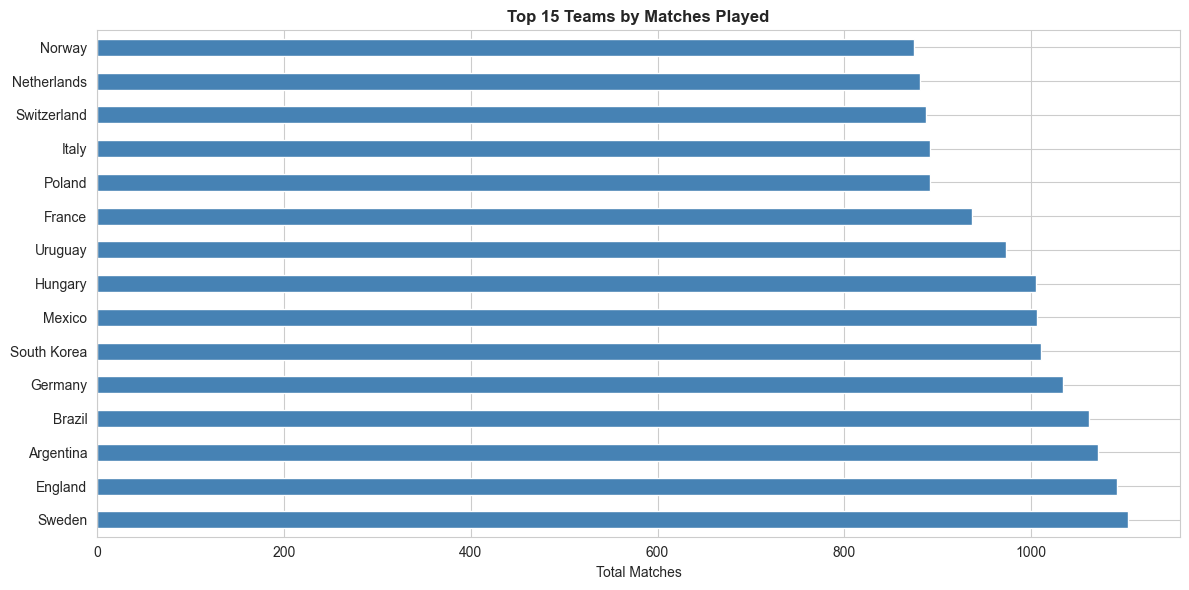

In [8]:
home_matches = results['home_team'].value_counts()
away_matches = results['away_team'].value_counts()
team_matches = home_matches.add(away_matches, fill_value=0).sort_values(ascending=False)

print("\nTop 15 Teams by Matches Played:")
print(team_matches.head(15))

plt.figure(figsize=(12, 6))
team_matches.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Total Matches')
plt.title('Top 15 Teams by Matches Played', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/01_top_teams.png', dpi=300, bbox_inches='tight')
plt.show()


Top 15 Most Successful Teams (by wins):
Brazil         672
England        624
Germany        599
Argentina      591
Sweden         541
South Korea    538
Mexico         514
France         476
Italy          476
Hungary        471
Spain          460
Netherlands    452
Uruguay        428
Scotland       402
Denmark        401
Name: count, dtype: int64


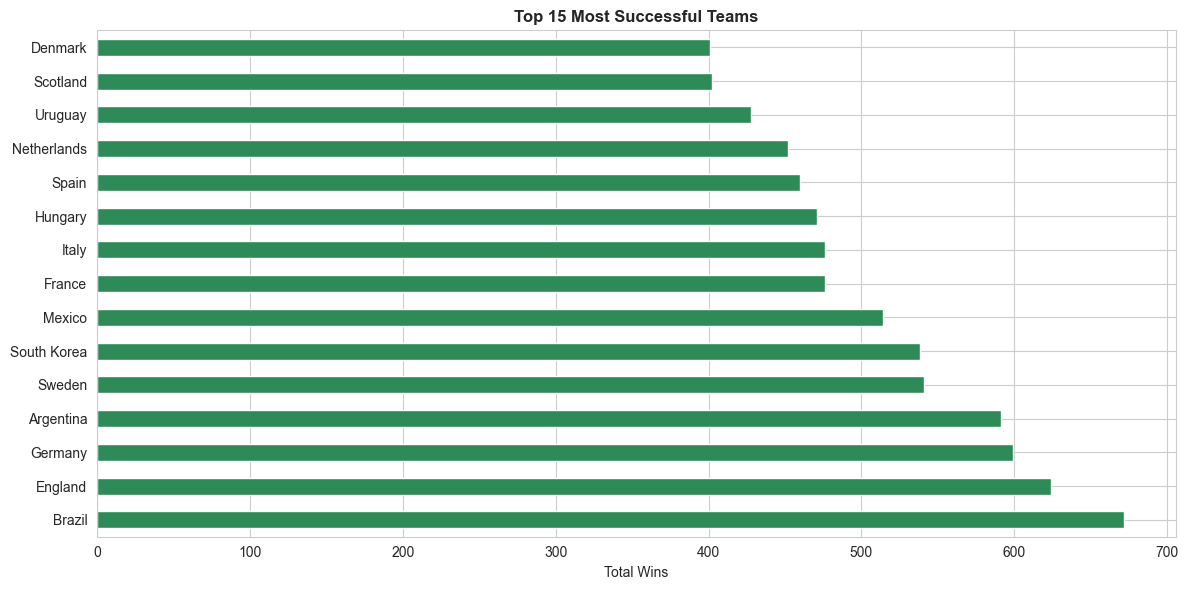

In [9]:
home_wins = results[results['home_score'] > results['away_score']]['home_team']
away_wins = results[results['away_score'] > results['home_score']]['away_team']
wins = pd.concat([home_wins, away_wins])
top_winners = wins.value_counts()

print("\nTop 15 Most Successful Teams (by wins):")
print(top_winners.head(15))

plt.figure(figsize=(12, 6))
top_winners.head(15).plot(kind='barh', color='seagreen')
plt.xlabel('Total Wins')
plt.title('Top 15 Most Successful Teams', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/02_most_successful_teams.png', dpi=300, bbox_inches='tight')
plt.show()


Top 15 Highest Scoring Teams:
England        2378.0
Germany        2320.0
Brazil         2305.0
Sweden         2171.0
Argentina      2025.0
Hungary        2008.0
Netherlands    1839.0
South Korea    1792.0
Mexico         1767.0
France         1712.0
Spain          1599.0
Denmark        1585.0
Italy          1564.0
Belgium        1550.0
Austria        1541.0
dtype: float64


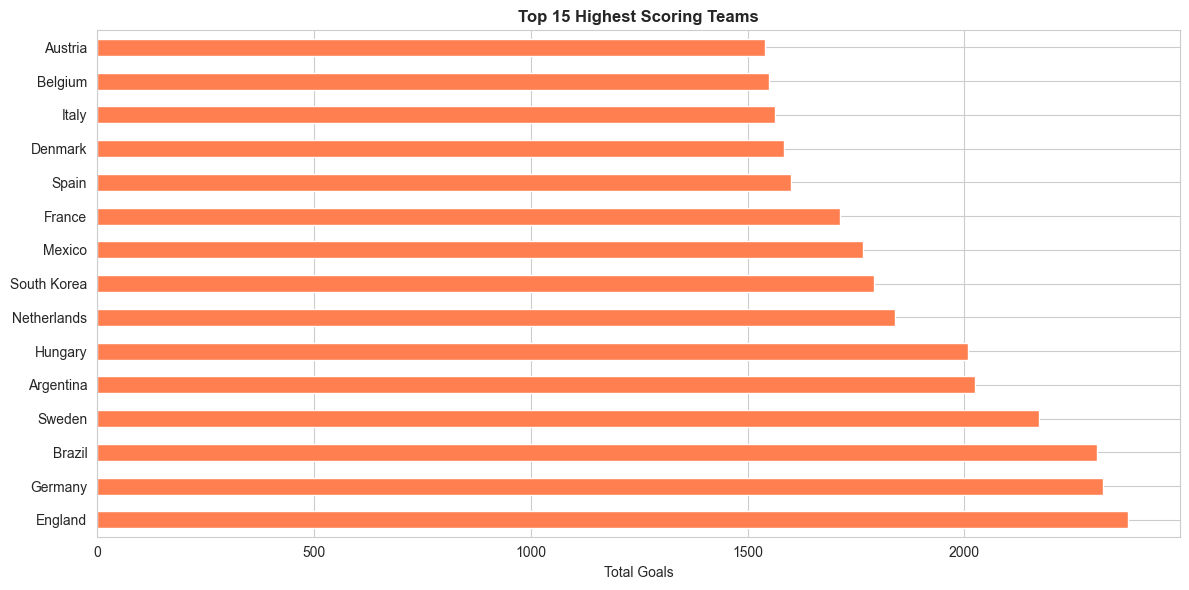

In [10]:
home_goals = results.groupby('home_team')['home_score'].sum()
away_goals = results.groupby('away_team')['away_score'].sum()
total_goals_by_team = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False)

print("\nTop 15 Highest Scoring Teams:")
print(total_goals_by_team.head(15))

plt.figure(figsize=(12, 6))
total_goals_by_team.head(15).plot(kind='barh', color='coral')
plt.xlabel('Total Goals')
plt.title('Top 15 Highest Scoring Teams', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/03_highest_scoring_teams.png', dpi=300, bbox_inches='tight')
plt.show()


Top 15 Teams with Best Defense (Fewest Goals Conceded):
Maule Sur         0.0
Elba Island       0.0
Saugeais          1.0
Asturias          1.0
Biafra            1.0
Surrey            1.0
Mapuche           2.0
Quebec            2.0
Cilento           2.0
Kurdistan         2.0
Yoruba Nation     2.0
Madrid            2.0
Canary Islands    3.0
Délvidék          3.0
Seborga           3.0
dtype: float64


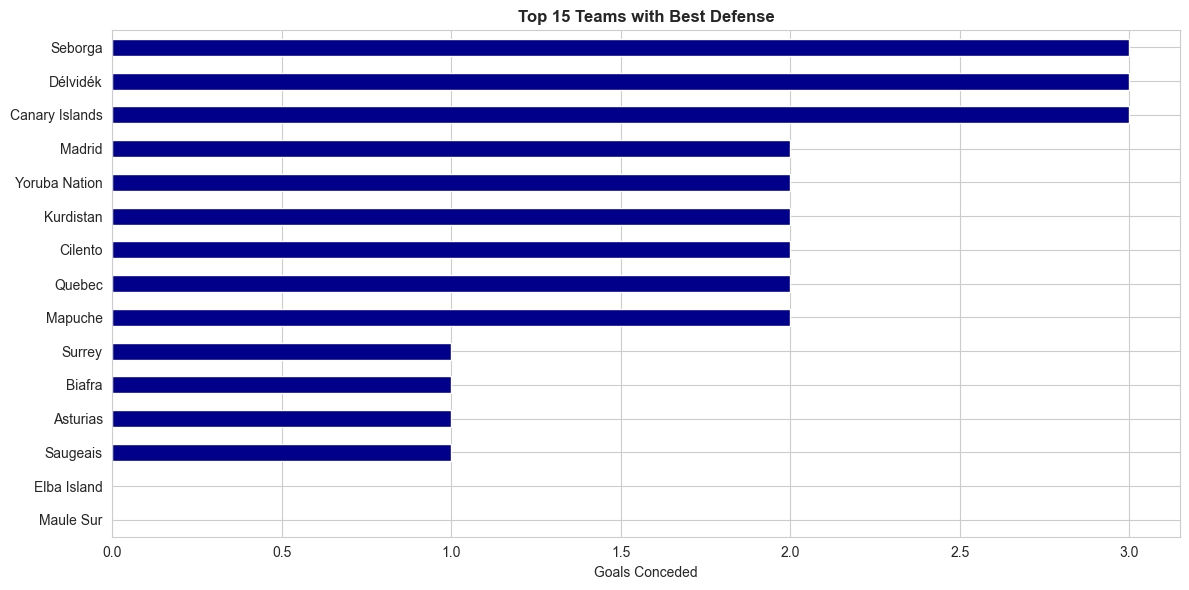

In [11]:
home_conceded = results.groupby('home_team')['away_score'].sum()
away_conceded = results.groupby('away_team')['home_score'].sum()
total_conceded = home_conceded.add(away_conceded, fill_value=0).sort_values()

print("\nTop 15 Teams with Best Defense (Fewest Goals Conceded):")
print(total_conceded.head(15))

plt.figure(figsize=(12, 6))
total_conceded.head(15).plot(kind='barh', color='darkblue')
plt.xlabel('Goals Conceded')
plt.title('Top 15 Teams with Best Defense', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/04_best_defense.png', dpi=300, bbox_inches='tight')
plt.show()


HOME ADVANTAGE ANALYSIS
Home Wins: 24,192 (63.4% of decisive matches)
Away Wins: 13,948 (36.6% of decisive matches)
Draws: 11,225 (22.7% of all matches)

Home teams win 26.9% more often than away teams


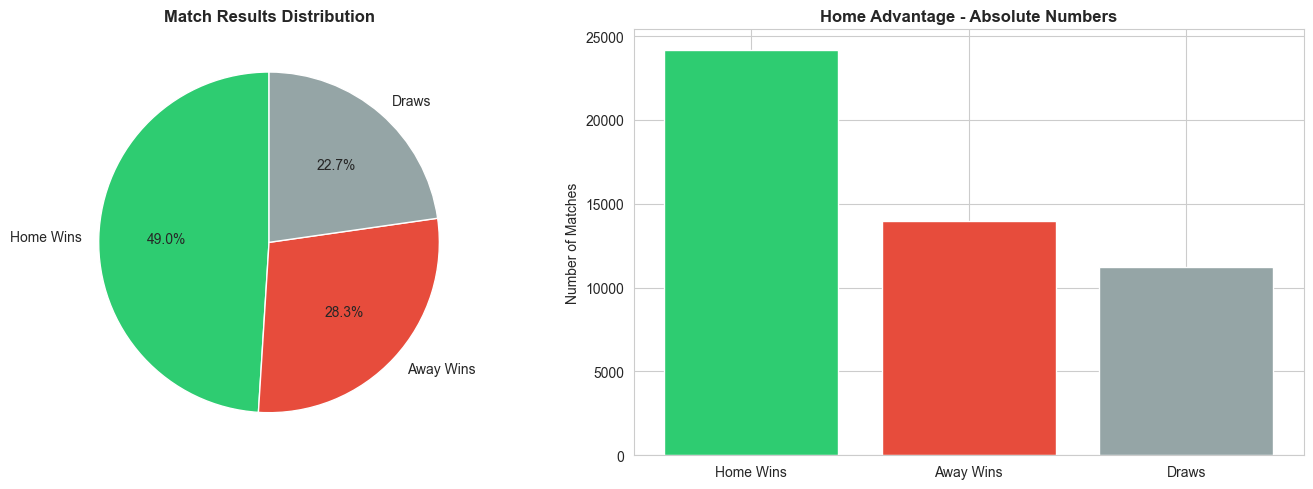

In [12]:
home_wins_count = len(results[results['home_score'] > results['away_score']])
away_wins_count = len(results[results['away_score'] > results['home_score']])
draws = len(results[results['home_score'] == results['away_score']])

total_decisive = home_wins_count + away_wins_count
home_win_pct = (home_wins_count / total_decisive) * 100
away_win_pct = (away_wins_count / total_decisive) * 100
draw_pct = (draws / len(results)) * 100

print("\n" + "="*50)
print("HOME ADVANTAGE ANALYSIS")
print("="*50)
print(f"Home Wins: {home_wins_count:,} ({home_win_pct:.1f}% of decisive matches)")
print(f"Away Wins: {away_wins_count:,} ({away_win_pct:.1f}% of decisive matches)")
print(f"Draws: {draws:,} ({draw_pct:.1f}% of all matches)")
print(f"\nHome teams win {home_win_pct - away_win_pct:.1f}% more often than away teams")
print("="*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#95a5a6']
ax1.pie([home_wins_count, away_wins_count, draws], 
        labels=['Home Wins', 'Away Wins', 'Draws'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Match Results Distribution', fontweight='bold')

ax2.bar(['Home Wins', 'Away Wins', 'Draws'], 
        [home_wins_count, away_wins_count, draws], 
        color=colors)
ax2.set_ylabel('Number of Matches')
ax2.set_title('Home Advantage - Absolute Numbers', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/05_home_advantage.png', dpi=300, bbox_inches='tight')
plt.show()


Goals Trend by Year (Last 10 Years):
      total_goals  matches  avg_goals
year                                 
2017       2511.0      924   2.717532
2018       2446.0      929   2.632939
2019       3327.0     1149   2.895561
2020        847.0      347   2.440922
2021       3076.0     1115   2.758744
2022       2437.0      969   2.514964
2023       3007.0     1054   2.852941
2024       3245.0     1231   2.636068
2025       2860.0     1002   2.854291
2026        768.0      344   2.232558


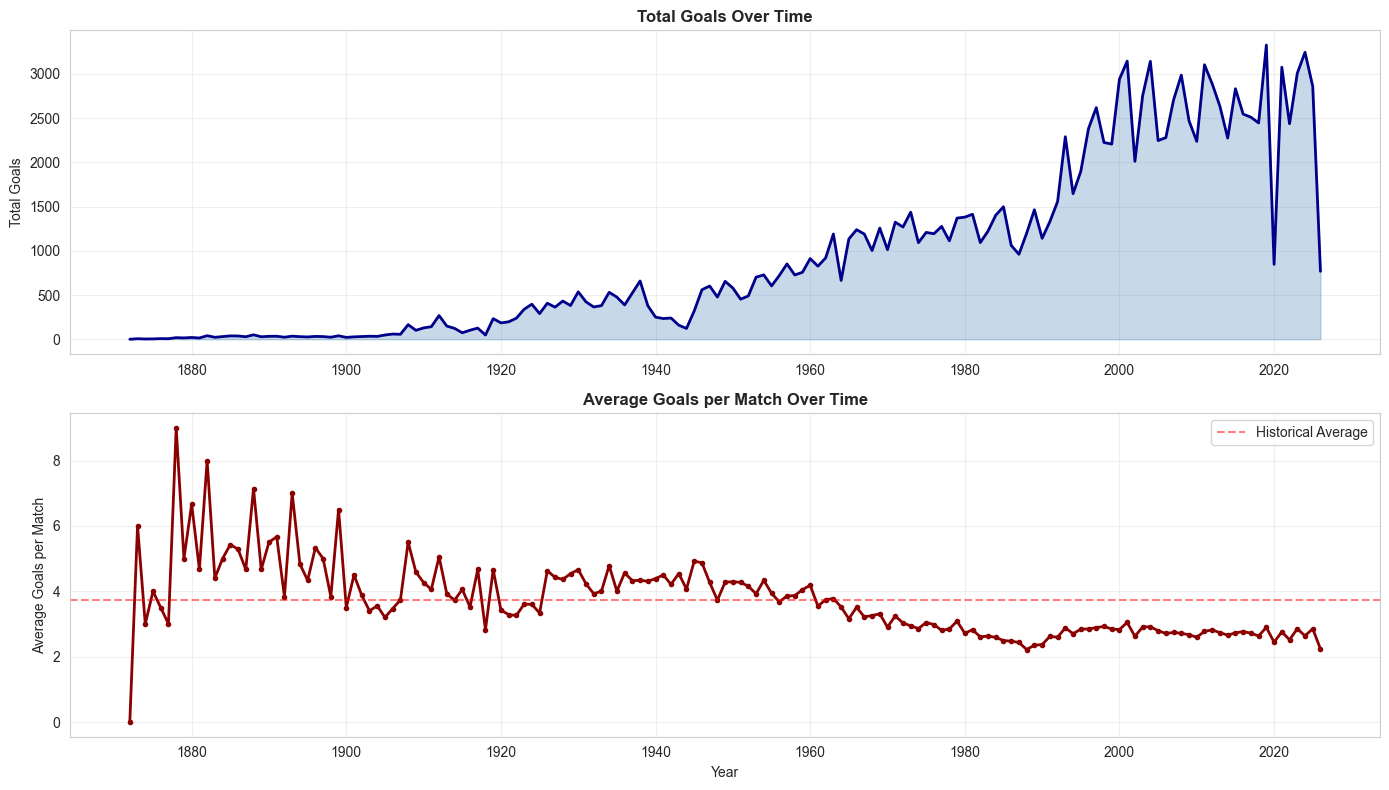

In [13]:
goals_per_year = results.groupby('year').agg({
    'total_goals': 'sum',
    'date': 'count'
}).rename(columns={'date': 'matches'})

goals_per_year['avg_goals'] = goals_per_year['total_goals'] / goals_per_year['matches']

print("\nGoals Trend by Year (Last 10 Years):")
print(goals_per_year.tail(10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(goals_per_year.index, goals_per_year['total_goals'], linewidth=2, color='darkblue')
ax1.fill_between(goals_per_year.index, goals_per_year['total_goals'], alpha=0.3, color='steelblue')
ax1.set_ylabel('Total Goals')
ax1.set_title('Total Goals Over Time', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(goals_per_year.index, goals_per_year['avg_goals'], linewidth=2, color='darkred', marker='o', markersize=3)
ax2.axhline(y=goals_per_year['avg_goals'].mean(), color='red', linestyle='--', alpha=0.5, label='Historical Average')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Goals per Match')
ax2.set_title('Average Goals per Match Over Time', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/06_goals_over_time.png', dpi=300, bbox_inches='tight')
plt.show()



Top 15 Tournaments by Match Count:
tournament
Friendly                                18356
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


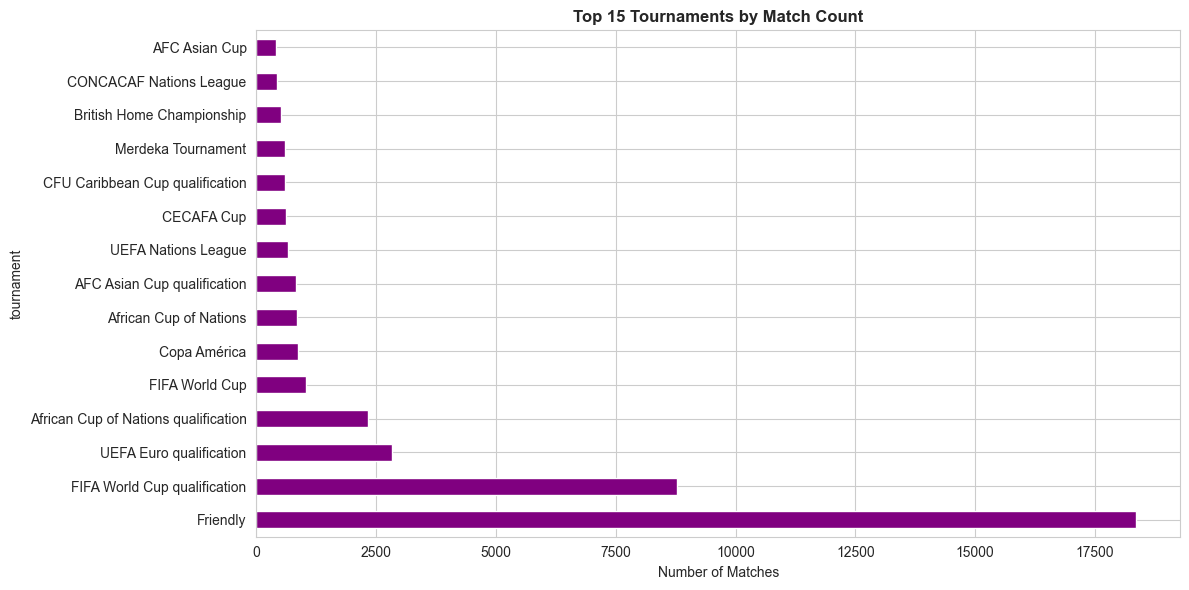


Tournaments with Highest Average Goals per Match (min 10 matches):
                                      Total_Goals  Avg_Goals_Per_Match  \
tournament                                                               
East Asian Games                            123.0                 7.24   
Inter-Allied Games                           87.0                 6.69   
South Pacific Games                        1212.0                 5.91   
GaNEFo                                       81.0                 5.79   
Central American and Caribbean Games        352.0                 5.59   
Pacific Games                               418.0                 5.57   
Soccer Ashes                                105.0                 5.00   
Olympic Games                               387.0                 4.96   
Pacific Mini Games                           72.0                 4.80   
Oceania Nations Cup qualification           148.0                 4.77   

                                      Match

In [14]:
tournament_counts = results['tournament'].value_counts()

print("\nTop 15 Tournaments by Match Count:")
print(tournament_counts.head(15))

plt.figure(figsize=(12, 6))
tournament_counts.head(15).plot(kind='barh', color='purple')
plt.xlabel('Number of Matches')
plt.title('Top 15 Tournaments by Match Count', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/07_tournaments.png', dpi=300, bbox_inches='tight')
plt.show()

tournament_goals = results.groupby('tournament').agg({
    'total_goals': ['sum', 'mean', 'count']
}).round(2)
tournament_goals.columns = ['Total_Goals', 'Avg_Goals_Per_Match', 'Matches']
tournament_goals = tournament_goals.sort_values('Avg_Goals_Per_Match', ascending=False)

print("\nTournaments with Highest Average Goals per Match (min 10 matches):")
print(tournament_goals[tournament_goals['Matches'] >= 10].head(10))


FORMER COUNTRY NAMES ANALYSIS

Total countries with name changes: 36
Unique current names: 28

Countries with multiple name changes:
current
DR Congo               4
Czechoslovakia         3
Russia                 2
Republic of Ireland    2
Serbia                 2
Name: count, dtype: int64

Former to Current Name Mappings:
Dahomey → Benin (1959-11-08 to 1975-11-30)
Upper Volta → Burkina Faso (1960-04-14 to 1984-08-04)
Netherlands Antilles → Curaçao (1957-03-03 to 2010-10-10)
Bohemia → Czechoslovakia (1903-04-05 to 1919-01-01)
Bohemia and Moravia → Czechoslovakia (1939-01-01 to 1945-05-01)
Representation of Czechs and Slovaks → Czechoslovakia (1993-03-24 to 1993-11-17)
Belgian Congo → DR Congo (1948-05-25 to 1956-01-02)
Congo-Léopoldville → DR Congo (1963-04-12 to 1964-07-19)
Congo-Kinshasa → DR Congo (1965-01-09 to 1970-11-24)
Zaïre → DR Congo (1971-01-10 to 1997-04-27)
French Somaliland → Djibouti (1947-12-05 to 1977-06-27)
United Arab Republic → Egypt (1958-02-22 to 1971-09-11)
Swa

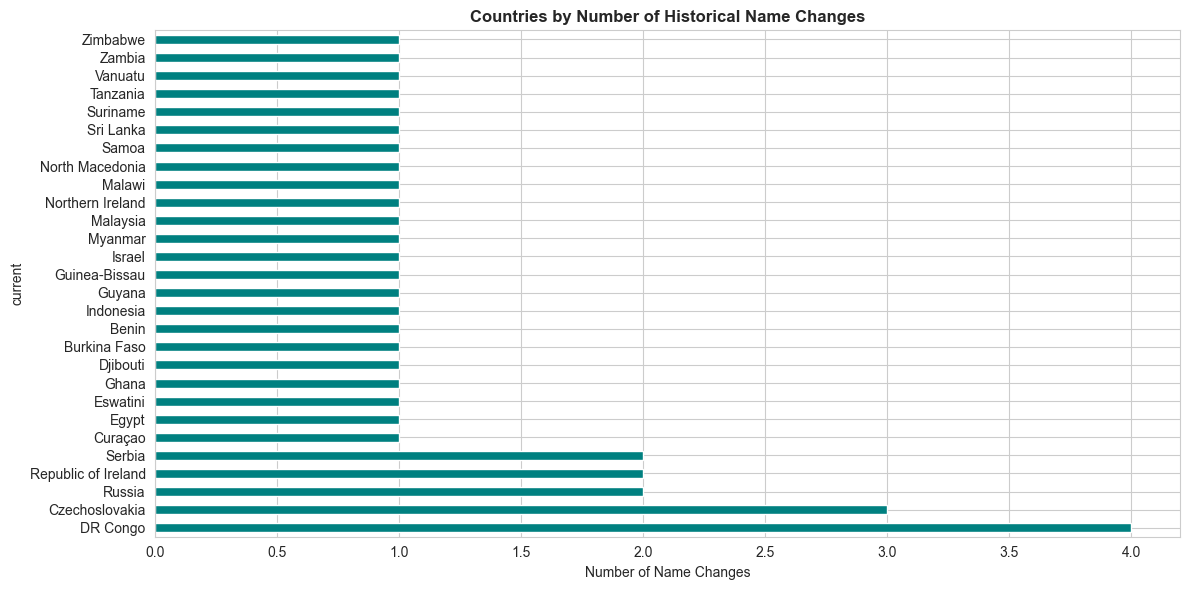

In [15]:
print("\n" + "="*50)
print("FORMER COUNTRY NAMES ANALYSIS")
print("="*50)

former_count = former.shape[0]
current_names = former['current'].nunique()

print(f"\nTotal countries with name changes: {former_count}")
print(f"Unique current names: {current_names}")

multiple_changes = former['current'].value_counts()
print("\nCountries with multiple name changes:")
print(multiple_changes[multiple_changes > 1])

print("\nFormer to Current Name Mappings:")
for idx, row in former.iterrows():
    print(f"{row['former']} → {row['current']} ({row['start_date'].date()} to {row['end_date'].date()})")

plt.figure(figsize=(12, 6))
former['current'].value_counts().plot(kind='barh', color='teal')
plt.xlabel('Number of Name Changes')
plt.title('Countries by Number of Historical Name Changes', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/08_former_names.png', dpi=300, bbox_inches='tight')
plt.show()


Top 20 All-Time Goal Scorers:
scorer
Cristiano Ronaldo      121
Harry Kane              69
Robert Lewandowski      69
Romelu Lukaku           64
Lionel Messi            63
Edin Džeko              58
Aleksandar Mitrović     52
Luis Suárez             51
Ali Daei                49
Miroslav Klose          48
Carlos Ruiz             47
Erling Haaland          46
Kylian Mbappé           45
Robbie Keane            44
Memphis Depay           44
Zlatan Ibrahimović      44
Clint Dempsey           41
David Villa             41
Andriy Shevchenko       40
Samuel Eto'o            40
Name: count, dtype: int64


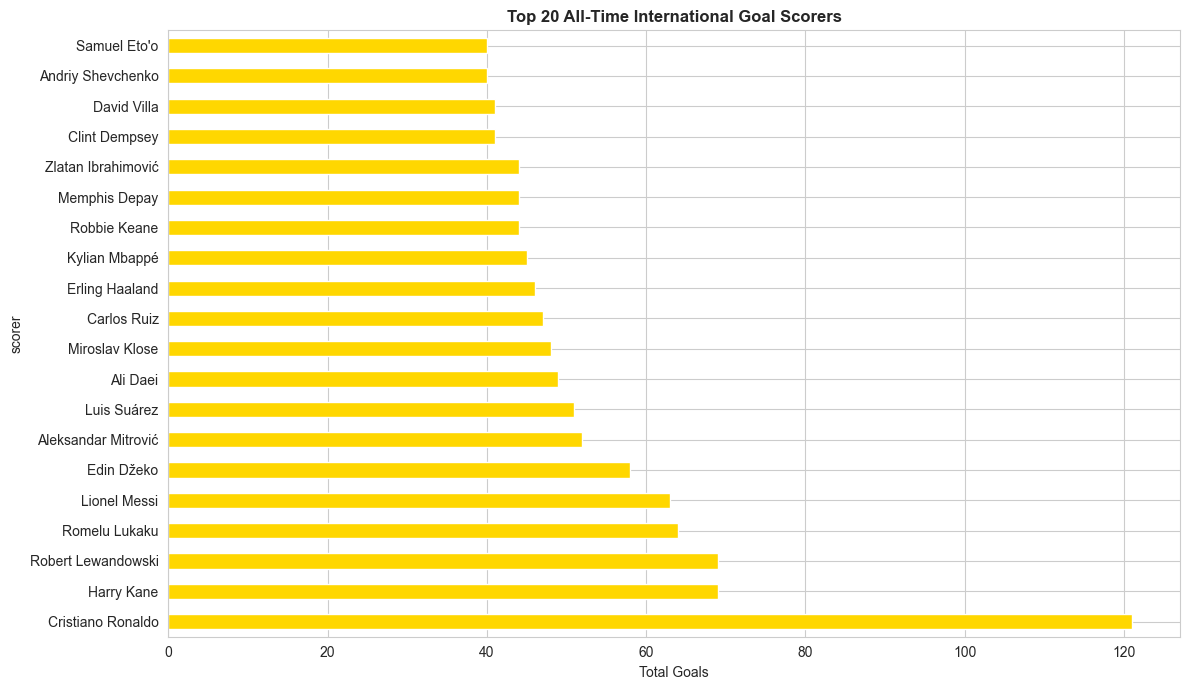


Top 15 Nations by Total Goals:
team
Brazil         1075
Germany        1014
Argentina       979
Spain           940
Netherlands     896
Mexico          862
Uruguay         826
England         813
France          802
Italy           761
Portugal        748
Belgium         724
Sweden          662
Australia       649
Russia          644
Name: count, dtype: int64


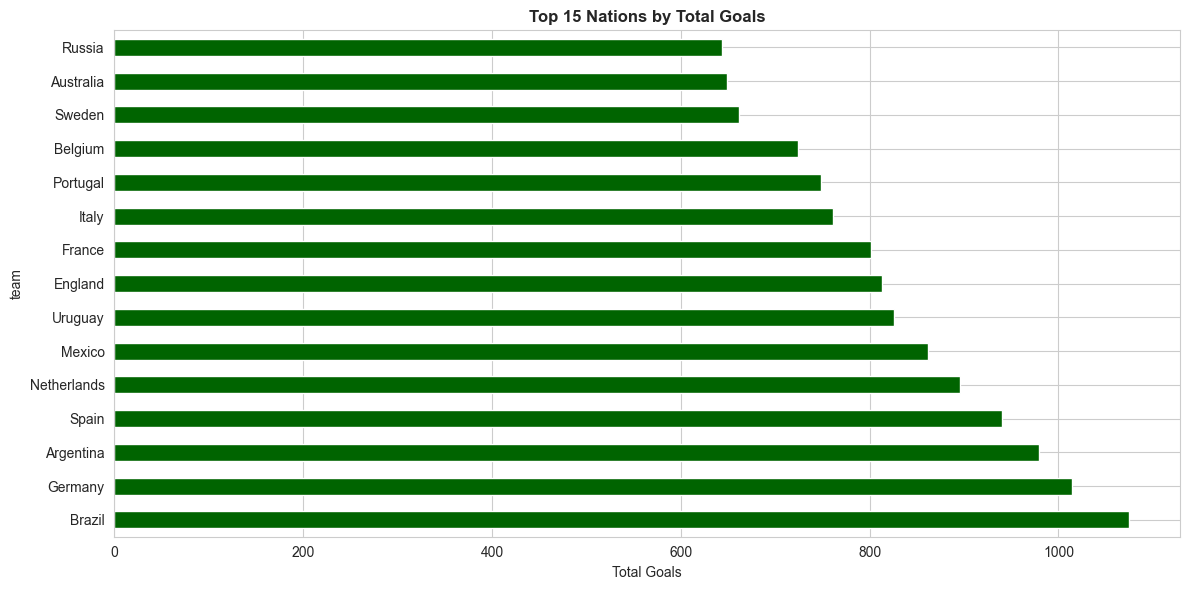

In [16]:
top_scorers = goals['scorer'].value_counts()

print("\nTop 20 All-Time Goal Scorers:")
print(top_scorers.head(20))

plt.figure(figsize=(12, 7))
top_scorers.head(20).plot(kind='barh', color='gold')
plt.xlabel('Total Goals')
plt.title('Top 20 All-Time International Goal Scorers', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/09_top_scorers.png', dpi=300, bbox_inches='tight')
plt.show()

top_nations = goals['team'].value_counts()

print("\nTop 15 Nations by Total Goals:")
print(top_nations.head(15))

plt.figure(figsize=(12, 6))
top_nations.head(15).plot(kind='barh', color='darkgreen')
plt.xlabel('Total Goals')
plt.title('Top 15 Nations by Total Goals', fontweight='bold')
plt.tight_layout()



GOAL TYPE BREAKDOWN
Regular Goals: 43,430 (91.2%)
Penalty Goals: 3,249 (6.8%)
Own Goals: 922 (1.9%)


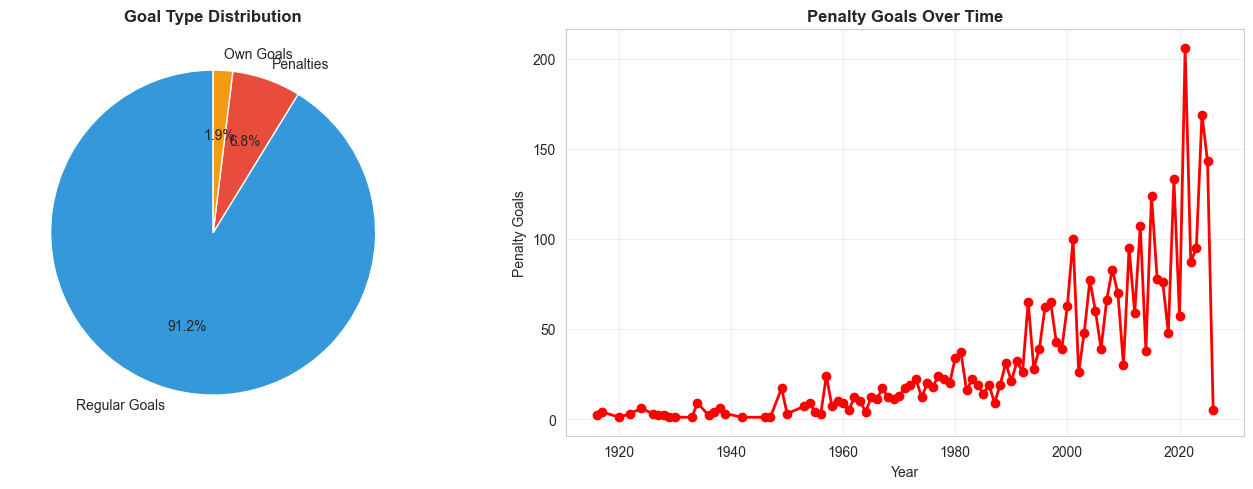

In [17]:
penalty_goals = goals['penalty'].sum()
own_goals = goals['own_goal'].sum()
regular_goals = len(goals) - penalty_goals - own_goals

print("\n" + "="*50)
print("GOAL TYPE BREAKDOWN")
print("="*50)
print(f"Regular Goals: {regular_goals:,} ({regular_goals/len(goals)*100:.1f}%)")
print(f"Penalty Goals: {int(penalty_goals):,} ({penalty_goals/len(goals)*100:.1f}%)")
print(f"Own Goals: {int(own_goals):,} ({own_goals/len(goals)*100:.1f}%)")
print("="*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e74c3c', '#f39c12']
ax1.pie([regular_goals, int(penalty_goals), int(own_goals)], 
        labels=['Regular Goals', 'Penalties', 'Own Goals'],
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Goal Type Distribution', fontweight='bold')

penalties_by_year = goals[goals['penalty']].groupby('year').size()
ax2.plot(penalties_by_year.index, penalties_by_year.values, linewidth=2, marker='o', color='red')
ax2.set_xlabel('Year')
ax2.set_ylabel('Penalty Goals')
ax2.set_title('Penalty Goals Over Time', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/10_top_nations.png', dpi=300, bbox_inches='tight')
plt.show()


PENALTY SHOOTOUT STATISTICS
Total Shootouts: 678
Year Range: 1967-2026
Winners analyzed: 183

Teams with Most Shootout Wins:
winner
South Korea     15
Argentina       15
Egypt           15
Zambia          14
Thailand        13
South Africa    13
Senegal         11
Iraq            11
Iran            10
Kenya           10
Name: count, dtype: int64


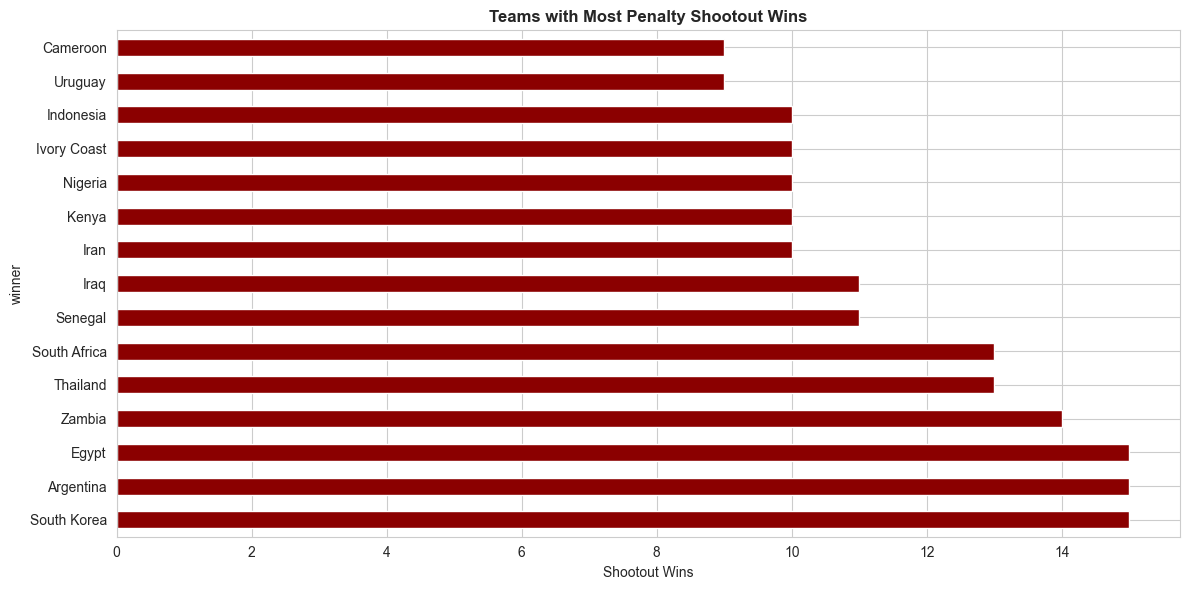


Shootouts per Year (Recent 10 Years):
year
2017    13
2018    18
2019    27
2020     4
2021    17
2022    26
2023    18
2024    24
2025    16
2026    14
dtype: int64


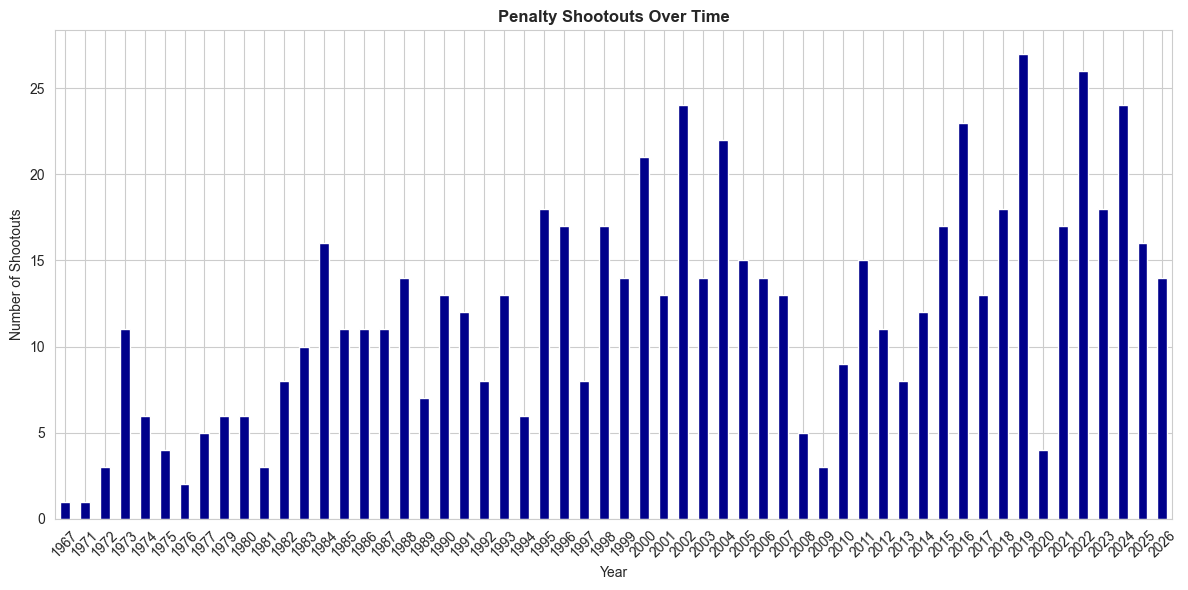

In [18]:
print("\n" + "="*50)
print("PENALTY SHOOTOUT STATISTICS")
print("="*50)
print(f"Total Shootouts: {len(shootouts)}")
print(f"Year Range: {shootouts['year'].min()}-{shootouts['year'].max()}")
print(f"Winners analyzed: {shootouts['winner'].nunique()}")
print("="*50)

shootout_winners = shootouts['winner'].value_counts()

print("\nTeams with Most Shootout Wins:")
print(shootout_winners.head(10))

plt.figure(figsize=(12, 6))
shootout_winners.head(15).plot(kind='barh', color='darkred')
plt.xlabel('Shootout Wins')
plt.title('Teams with Most Penalty Shootout Wins', fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/11_goal_types.png', dpi=300, bbox_inches='tight')
plt.show()

shootouts_per_year = shootouts.groupby('year').size()

print("\nShootouts per Year (Recent 10 Years):")
print(shootouts_per_year.tail(10))

plt.figure(figsize=(12, 6))
shootouts_per_year.plot(kind='bar', color='darkblue')
plt.xlabel('Year')
plt.ylabel('Number of Shootouts')
plt.title('Penalty Shootouts Over Time', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()



DESCRIPTIVE STATISTICS - GOALS
       home_score  away_score  total_goals
count   49365.000   49365.000    49365.000
mean        1.757       1.182        2.939
std         1.775       1.402        2.096
min         0.000       0.000        0.000
25%         1.000       0.000        1.000
50%         1.000       1.000        3.000
75%         2.000       2.000        4.000
max        31.000      21.000       31.000


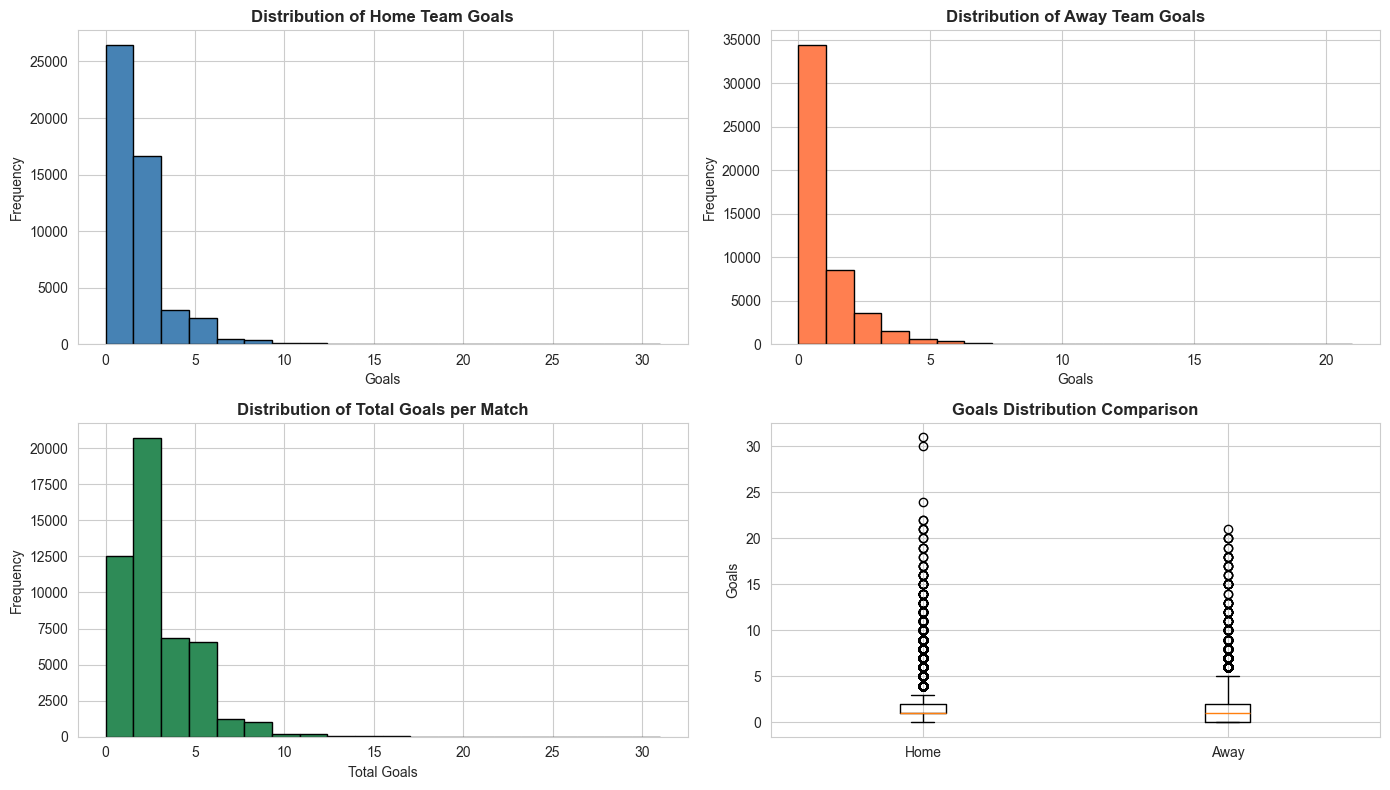


CORRELATION MATRIX
            home_score  away_score
home_score    1.000000   -0.145248
away_score   -0.145248    1.000000


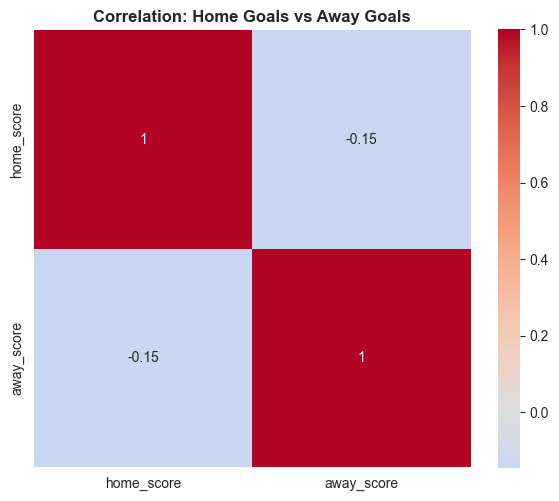

In [19]:
print("\n" + "="*50)
print("DESCRIPTIVE STATISTICS - GOALS")
print("="*50)
print(results[['home_score', 'away_score', 'total_goals']].describe().round(3))
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(results['home_score'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Home Team Goals', fontweight='bold')
axes[0, 0].set_xlabel('Goals')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(results['away_score'].dropna(), bins=20, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Away Team Goals', fontweight='bold')
axes[0, 1].set_xlabel('Goals')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(results['total_goals'], bins=20, color='seagreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Total Goals per Match', fontweight='bold')
axes[1, 0].set_xlabel('Total Goals')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].boxplot([results['home_score'].dropna(), results['away_score'].dropna()],
                     labels=['Home', 'Away'])
axes[1, 1].set_title('Goals Distribution Comparison', fontweight='bold')
axes[1, 1].set_ylabel('Goals')

plt.tight_layout()
plt.savefig('visualizations/12_shootout_winners.png', dpi=300, bbox_inches='tight')
plt.show()

correlation = results[['home_score', 'away_score']].corr()

print("\nCORRELATION MATRIX")
print(correlation)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation: Home Goals vs Away Goals', fontweight='bold')
plt.tight_layout()


In [20]:
print("\n" + "="*60)
print("KEY INSIGHTS SUMMARY")
print("="*60)

print(f"\n1. HOME ADVANTAGE")
print(f"   • Home teams win {home_win_pct:.1f}% of decisive matches")
print(f"   • Away teams win {away_win_pct:.1f}% of decisive matches")
print(f"   • Difference: {home_win_pct - away_win_pct:.1f} percentage points")

regular = regular_goals / len(goals) * 100
pens = penalty_goals / len(goals) * 100
own = own_goals / len(goals) * 100
print(f"\n2. GOALSCORING PATTERNS")
print(f"   • Regular goals: {regular:.1f}%")
print(f"   • Penalty goals: {pens:.1f}%")
print(f"   • Own goals: {own:.1f}%")

print(f"\n3. TOP PERFORMING NATIONS")
for i, (team, w) in enumerate(top_winners.head(5).items(), 1):
    print(f"   {i}. {team}: {w:,} wins")

print(f"\n4. TOP GOAL SCORERS")
for i, (scorer, g) in enumerate(top_scorers.head(5).items(), 1):
    print(f"   {i}. {scorer}: {g} goals")

print(f"\n5. DATA COVERAGE")
print(f"   • Time period: {results['year'].min()}-{results['year'].max()}")
print(f"   • Total matches: {total_matches:,}")
print(f"   • Total teams: {total_teams}")
print(f"   • Tournament types: {total_tournaments}")
print(f"   • Unique scorers: {total_scorers:,}")
print(f"   • Penalty shootouts: {total_shootouts}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)


KEY INSIGHTS SUMMARY

1. HOME ADVANTAGE
   • Home teams win 63.4% of decisive matches
   • Away teams win 36.6% of decisive matches
   • Difference: 26.9 percentage points

2. GOALSCORING PATTERNS
   • Regular goals: 91.2%
   • Penalty goals: 6.8%
   • Own goals: 1.9%

3. TOP PERFORMING NATIONS
   1. Brazil: 672 wins
   2. England: 624 wins
   3. Germany: 599 wins
   4. Argentina: 591 wins
   5. Sweden: 541 wins

4. TOP GOAL SCORERS
   1. Cristiano Ronaldo: 121 goals
   2. Harry Kane: 69 goals
   3. Robert Lewandowski: 69 goals
   4. Romelu Lukaku: 64 goals
   5. Lionel Messi: 63 goals

5. DATA COVERAGE
   • Time period: 1872-2026
   • Total matches: 49,437
   • Total teams: 336
   • Tournament types: 200
   • Unique scorers: 15,334
   • Penalty shootouts: 678

ANALYSIS COMPLETE!


In [22]:
import os

# Create folder once at start
os.makedirs('visualizations', exist_ok=True)

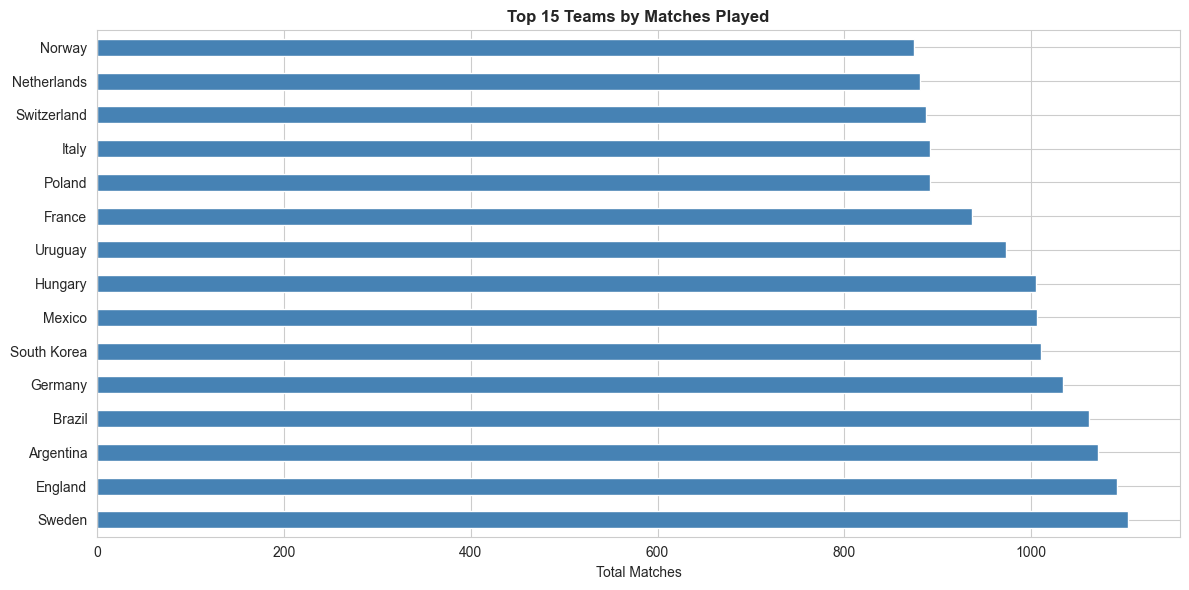

In [23]:
# Example - SECTION 7: TOP TEAMS

plt.figure(figsize=(12, 6))
team_matches.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Total Matches')
plt.title('Top 15 Teams by Matches Played', fontweight='bold')
plt.tight_layout()

# ADD THIS LINE BEFORE plt.show()
plt.savefig('visualizations/01_top_teams.png', dpi=300, bbox_inches='tight')

plt.show()

In [25]:
# Removed incorrect savefig block

<Figure size 640x480 with 0 Axes>

In [26]:
import os
os.makedirs('visualizations', exist_ok=True)
print("✓ Folder created")

✓ Folder created
